# 주피터 서버코드를 옮기는 과정에서 변경점

이 노트북은 기존 강의 코드의 **프록시 서버 방식(PROXY_TOKEN, PROXY_URL)** 을 로컬 환경에 맞춰 **.env의 OPENAI_API_KEY를 사용하는 방식**으로 바꾼 버전입니다.

`.env` 파일 예시:

```env
OPENAI_API_KEY=당신의 OPENAI_API_KEY를 입력해주세요
```

핵심 변경점:
- `load_dotenv()`로 `.env` 로드
- `ChatOpenAI(...)` 또는 `init_chat_model(...)`이 자동으로 `OPENAI_API_KEY`를 사용하도록 변경

### API KEY 및 환경설정

In [ ]:
# =============================
# 0. API KEY 및 환경 설정
# =============================


# os 모듈은 운영체제 환경변수에 접근할때 사용함
import os

# LangChain에서 채팅 모델을 간단히 초기화하기위한 함수입니다.
# init_chat_model('gpt-4o-mini')처럼 모델 이름만 넣어도 사용할 수 있습니다.
from langchain.chat_models import init_chat_model

# python-dotenv라이브러리의 load_dotenv 함수입니다.
# .env 파일 안에 적어둔 API 키를 현재 파이썬 실행 환경의 환경변수로 불러옵니다.
from dotenv import load_dotenv

# 현재 노트북과 같은 폴더 또는 프로젝트 루트에 있는 .env 파일을 읽습니다.
# .env 예시:
# OPENAI_API_KEY=당신의 OpenAI_API_KEY

# 기존 강의 코드에서는 PROXY_TOKEN, PROXY_URL을 사용했지만,
# Local로 돌릴경우 본인 OPEN API키를 .env에 넣어두었으므로 OPEN_API_KEY만 사용하면 됩니다.
load_dotenv()

# 혹시 .env가 제대로 로드되지 않았을 때 바로 원인을 알 수 있도록 체크합니다.
# API키 전체를 출력하면 보안상 윟머하므로, 존재 여부만 확인합니다.
if not os.getenv('OPENAI_API_KEY'):
    raise ValueError('OPENAI_API_KEY가 없습니다. .env파일에 OPEN_API_KEY=... 형태로 저장했는지 확인하세요.')

# 사용할 LLM 모델을 초기화합니다.
# temperature=0은 답변을 최대한 일관되게 만들기 위한 설정입니다.
# 값이 높아질수록 더 창의적이지만 매번 달라질 가능성이 커집니다.
model = init_chat_model(
    "gpt-4o-mini", # 사용할 OpenAI 모델명
    temperature = 0 # 동일 입력에 대한 안정적인 답변 유도 1에 가깝게 설정하면 다양한 답변 발생
)

# Multi-agent
* 복잡한 workflow 개념이 아닌 하위 agent 개념의 agent
  * 더 복잡한 workflow는 langgraph로 구현가능
* Tool 기반 하위 agent를 구현하는 방식으로 Multi-agent 구현

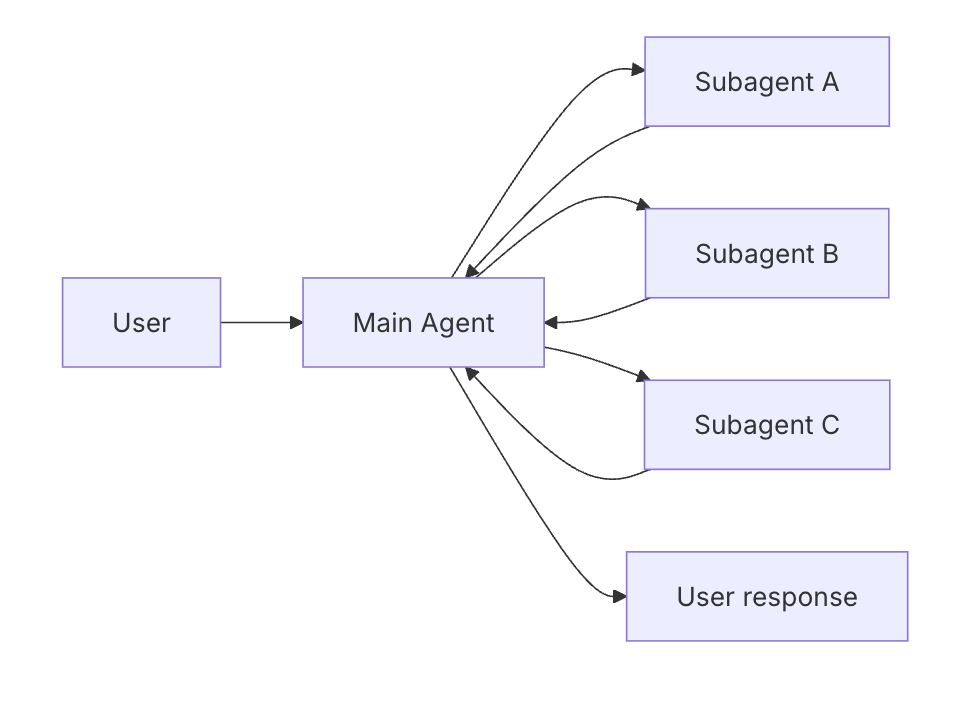

* 간단히 Agent가 Tool로 Agent를 부르며 Context window를 독립해 작업을 실행합니다.

### Subagent 구현하기
* Tool 형태로 subagent를 구현합니다.

### Skills

### 직장인 휴가 요청 -> 등록(LangChain 에이전트) 예제 (더미)

### 개요
이 문서는 **LangChain 에이전트**를 사용하여
직장인이 **휴가 요청 -> HR시스템에 등록(더미)**까지 처리하는 흐름을 설명하는 예제입니다.
실제 DB나 사내 시스템과 연동하지 않고, **동작 구조를 이해하기 위한 더미 코드**를 전제로 합니다.

---

### 핵심포인트

- **Skills 구조**
  - `load_skill()` 함수가 **파일이나 DB를 참조하지 않고**
  - **Markdown 텍스트를 직접 return** 하도록 구성됩니다.

- **에이전트 동작 흐름**
  1. 사용자의 입력을 분석합니다.
  2. 휴가 요청과 관련된 경우
    `load_skill("request_vacation")`을 호출하여 휴가 정책 및 필요한 입력 항목을 로드합니다.
  3. 필요한 정보(휴가 종류, 기간, 사유 등)를 정리합니다.
  4. `register_vacation_request()` 더미 툴을 호출합니다.
  5. 실제로는 저장하지 않지만 **"등록된 것처럼" 결과를 반환**합니다.

- **휴가 등록 처리**
  - HR 시스템은 실제 연동되지 않습니다.
  - 요청 번호, 상태 등은 **더미 데이터**로 생성됩니다.

In [7]:
# =============================
# 1. 휴가 요청 Skill + 등록 Tool 예제
# =============================


# Optional: 값이 있을 수도 있고 없을 수도 있음을 표현할 때 사용하는 타입 힌트입니다.
# Dict, Any: 딕셔너리 형태의 데이터 구조를 설명할 때 사용합니다.
from typing import Optional, Dict, Any

# 문자열 날짜를 실제 날짜 객체로 바꾸거나, 현재 시간을 만들 때 사용하는 표준 라이브러리입니다.
from datetime import datetime

# @tool 데코레이터를 사용하면 일반 파이썬 함수를 LangChain Agent가 호출할 수 있는 "도구"로 바꿀 수 있습니다.
from langchain.tools import tool

# create_agent는 LLM + Tool을 묶어서 Agent를 만들어주는 함수입니다. 
from langchain.agents import create_agent


# --------------------------------------------------
# 1) Skill Loader
# --------------------------------------------------
# Skill은 "특정 업무를 잘 처리하기 위한 상세 지침서"라고 이해하면 됩니다.
# 여기서는 실제 파일을 읽지 않고, 함수 안에서 마크다운 문자열을 바로 반환합니다.
# 
# 예를 들어 사용자가 "휴가 등록해줘"라고 하면,
# Agent는 load_skill('request_vacation') 도구를 호출해서
# 휴가 처리 규칙을 먼저 읽고, 그 규칙에 맞게 다음 행동을 결정할 수 있습니다.
@tool
def load_skill(skill_name: str) -> str:
    # 함수의 역할과 사용 가능한 스킬 목록을 설명하는 독스트링입니다.
    """Load a specialized skill prompt as markdown text.

    Available skills:
    - request_vacation: 휴가 요청/등록 도우미
    - review_legal_doc: (예시용) 법률 문서 리뷰어
    """
    # 요청된 스킬이 휴가 요청 스킬인 경우 해당 마크다운을 반환합니다.
    if skill_name == "request_vacation":
        return """# ✅ Skill: request_vacation (휴가 요청/등록)

                ## 목적
                직장인의 휴가 요청을 표준 포맷으로 정리하고, HR 시스템(더미)에 등록합니다.

                ## 입력으로 확보해야 할 정보(필수)
                - 휴가 종류: 연차/반차/병가/기타
                - 기간: 시작일 ~ 종료일 (YYYY-MM-DD)
                - 사유(짧게)
                - 인수인계 내용(짧게)
                - 대체 담당자(있으면)

                ## 규칙(더미 정책)
                - 시작일은 종료일보다 늦을 수 없습니다.
                - 과거 날짜만으로 신청하면 경고(더미).
                - 사유는 5자 이상 권장.

                ## 출력 포맷(최종 답변)
                - 요약(휴가 종류, 기간, 일수 추정)
                - 등록 결과(요청번호, 상태)
                - 유의사항(필요 시)
                    """
    # 요청된 스킬이 법률 문서 리뷰 스킬인 경우 간단한 마크다운을 반환합니다.
    if skill_name == "review_legal_doc":
        return """# Skill: review_legal_doc (더미) 법률 문서 리뷰어"""

    # 정의되지 않은 스킬 이름이 들어오면 안내 문구를 반환합니다.
    return f"# Unknown skill: {skill_name}\n사용 가능한 skill_name을 확인해주세요."

# --------------------------------------------------
# 2) 휴가 등록 더미 Tool
# --------------------------------------------------
# 실제 회사 HR 시스템에 저장하는 코드는 아니고,
# "등록된 것처럼" 결과를 만들어 Agent 동작 흐름을 연습하기 위한 더미 함수입니다.
@tool
def register_vacation_request(
    vacation_type: str,
    start_date: str,
    end_date: str,
    reason: str,
    employee_name: Optional[str] = None,
) -> Dict[str, Any]:
    """
    휴가 요청 정보를 더미 HR 시스템에 등록합니다.

    Args:
        vacation_type: 휴가 종류. 예 연차, 반차, 병가
        start_date: 휴가 시작일. 예: 2026-05-01
        end_date: 휴가 종료일. 예: 2026-05-03
        reason: 휴가 사유
        employee_name: 직원 이름. 없으면 미기재로 처리

    Returns:
        등록 결과를 담은 딕셔너리
    """
    # 시작일 문자열을 datetime 객체로 변환합니다.
    start_date = datetime.strptime(start_date, '%Y-%m-%d')

    # 종료일 문자열을 datetime 객체로 변환합니다.
    end_date = datetime.strptime(end_date, '%Y-%m-%d')

    # 시작일이 종료일보다 늦으면 오류 결과를 반환합니다.
    if start_date > end_date:
        return {
            'ok': False, # 등록 실패 여부를 나타냅니다.
            'error': 'start_date가 end_date보다 늦습니다.' # 오류 메시지를 담습니다.
        }


    # # 시작일, 직원명 첫 글자, 종료일을 조합해 더미 요청번호를 생성합니다.
    request_id = f"VAC-{start_date.strftime('%Y%m%d')}-{employee_name[:1].upper()}-{end_date.strftime('%m%d')}"

    return {
        "request_id": request_id,
        'status': 'submitted',
        'employee_name': employee_name or '미기재',
        'vacation_type': vacation_type,
        'start_date': start_date,
        'end_date': end_date,
        'reason': reason,
        'message': '휴가 요청이 더미 HR시스템에 등록되었습니다.'
    }

# --------------------------------------------------
# 3) 휴가 처리 Agent 생성
# --------------------------------------------------
# 이 Agent는 두가지 도구를 사용할 수 있습니다.
# - load_skill: 업무 지침 불러오기
# - register_vacation_request: 휴가 요청 등록하기
# load_skill과 register_vacation_request 도구를 사용하는 메인 에이전트를 생성합니다.
main_agent = create_agent(
    model=model,  # 미리 정의된 모델을 메인 에이전트에 연결합니다.
    tools=[load_skill, register_vacation_request],  # 사용할 도구 목록을 등록합니다.
    system_prompt=(
        "당신은 직장에서 근무하는 사용자를 돕는 사무 보조 어시스턴트입니다." 
        "사용자가 휴가를 요청하려는 경우 다음 절차를 따르세요:" 
        "1) load_skill('request_vacation')을 호출하여 휴가 정책과 필수 입력 항목을 불러옵니다."
        "2) 사용자 입력에서 필수 정보를 추출하거나, 부족한 정보가 있으면 간단히 질문합니다."
        "3) register_vacation_request를 호출하여 휴가 요청을 등록합니다(더미 처리)."
        "4) 휴가 요청 요약과 등록 결과를 정리하여 명확하게 반환합니다."
        "사용자의 입력이 불명확한 경우, 짧고 정중한 확인 질문을 합니다." 
    ),
)

# --------------------------------------------------
# 4) 실행 예시
# --------------------------------------------------
# 아래 코드를 실행하면 Agent가 사용자의 자연어 요청을 읽고,
# 필요한 경우 도구를 호출해 더미 휴가 등록을 수행합니다.

# 실제 휴가 요청 문장을 예제로 query 변수에 저장합니다.
query = "연차 휴가를 2026-02-10부터 2026-02-12까지 신청해서 등록해줘. 사유는 가족 행사. 인수인계는 진행 중인 A프로젝트 문서 업데이트해둘게. 대체자는 김대리."

# 사용자 질의와 구분선을 출력합니다.
print(f"User Query: {query}\n" + "=" * 50)

# 메인 에이전트에 사용자 메시지를 전달하여 실행합니다.
result = main_agent.invoke({
    "messages": [{"role": "user", "content": query}]  # 사용자 질의를 메시지 형식으로 전달합니다.
})

# 최종 결과 제목을 출력합니다.
print(f"\n[Final Answer]:")

print('-' * 50)
# 메인 에이전트의 마지막 응답 메시지 내용을 출력합니다.
print(result['messages'][-1].content)


User Query: 연차 휴가를 2026-02-10부터 2026-02-12까지 신청해서 등록해줘. 사유는 가족 행사. 인수인계는 진행 중인 A프로젝트 문서 업데이트해둘게. 대체자는 김대리.

[Final Answer]:
--------------------------------------------------
휴가 요청이 성공적으로 등록되었습니다. 아래는 요청 요약입니다:

- **휴가 종류**: 연차
- **기간**: 2026-02-10 ~ 2026-02-12
- **사유**: 가족 행사
- **인수인계 내용**: A프로젝트 문서 업데이트
- **대체 담당자**: 김대리

**등록 결과**:
- **요청번호**: VAC-20260210-김-0212
- **상태**: 제출됨

휴가 요청이 더미 HR 시스템에 등록되었습니다. 추가로 필요한 사항이 있으면 말씀해 주세요!


In [31]:
# LangChain의 tool 데코레이터를 불러옵니다.
from langchain.tools import tool

# LangChain 에이전트를 생성하는 함수를 불러옵니다.
from langchain.agents import create_agent

# ---------------------------
# Sub Agent
# ---------------------------

# 별도 도구 없이 동작하는 서브 에이전트를 생성합니다.
subagent = create_agent(
    model=model, # 미리 정의된 모델을 서브 에이전트에 연결합니다.
    tools=[] # 서브 에이전트는 별도의 도구 없이 동작합니다.
)

# ---------------------------
# Tool 정의 (로그 추가)
# ---------------------------

# research라는 이름의 도구를 정의합니다.
@tool(
    'research', # 도구의 이름을 research로 지정합니다.
    description='연구 주제를 기반으로 답변을 검색 혹은 생성하세요.' # 도구의 역할을 설명합니다.
)

# 서브 에이전트를 호출하는 research 도구 함수를 정의합니다.
def call_research_agent(query: str):
    # 도구가 호출되었음을 콘솔에 출력합니다.
    print("🛠️ [TOOL CALLED] research tool invoked")

    # 입력받은 질의를 콘솔에 출력합니다.
    print(f"📝 Query: {query}")

    # 서브 에이전트에 사용자 메시지 형태로 질의를 전달하여 실행합니다.
    result = subagent.invoke({
        'messages': [
            {'role': 'user', 'content': query} # query를 사용자 메시지로 전달합니다.
        ]
    })

    # 서브 에이전트의 마지막 응답 메시지 내용을 추출합니다.
    output = result['messages'][-1].content

    # 도구 실행 결과가 나왔음을 콘솔에 출력합니다.
    print("✅ 서브 에이전트의 [TOOL RESULT]")

    # 추출한 결과 내용을 콘솔에 출력합니다.
    print(output)

    # 메인 에이전트가 사용할 수 있도록 결과를 반환합니다.
    return output


# ---------------------------
# Main Agent
# ---------------------------

# research 도구를 사용할 수 있는 메인 에이전트를 생성합니다.
main_agent = create_agent(
    model=model, # 미리 정의된 모델을 메인 에이전트에 연결합니다.
    tools=[call_research_agent], # 메인 에이전트가 사용할 도구로 research 도구를 등록합니다.
    system_prompt=(
        "당신은 메인 에이전트입니다. " # 에이전트의 역할을 정의합니다.
        "사용자가 리서치나 사실 확인이 필요한 조사성 질문을 할 경우, " # 어떤 상황에서 도구를 써야 하는지 지정합니다.
        '반드시 리서치 도구를 사용해야 합니다.' # 조사성 질문에는 반드시 research 도구를 사용하도록 강제함.
    )
)

# ---------------------------
# 실행 예제
# --------------------------- 

# 메인 에이전트에 사용자 질문을 전달하여 실행합니다.
response = main_agent.invoke({
    "messages": [
        {
            'role': 'user', # 사용자 역할의 메시지임을 나타냅니다.
            'content': 'sk하이닉스와 삼성전자의 협업 관계를 조사해줘' # 조사성 질문을 전달합니다.
        }
    ]
})

# 최종 응답 출력전 구분용 문구를 출력합니다.
print("\n🤖 [MAIN AGENT FINAL RESPONSE]")

# 메인에이전트의 마지막 응답 메시지 내용을 출력합니다.
print(response['messages'][-1].content)

🛠️ [TOOL CALLED] research tool invoked
📝 Query: SK hynix and Samsung Electronics collaboration relationship
✅ 서브 에이전트의 [TOOL RESULT]
As of my last knowledge update in October 2023, SK hynix and Samsung Electronics are two of the largest semiconductor manufacturers in the world, particularly known for their production of memory chips, including DRAM and NAND flash memory. While they are competitors in the semiconductor market, they have also engaged in collaborations and partnerships in various contexts.

1. **Industry Collaboration**: Both companies are part of the broader semiconductor ecosystem and have occasionally collaborated on industry standards and initiatives. This can include joint efforts in research and development, particularly in areas like next-generation memory technologies and manufacturing processes.

2. **Supply Chain Dynamics**: Given the competitive nature of the semiconductor industry, both companies have to navigate complex supply chain dynamics. They may collabo

# Subagent 기반 데이터 분석 파이프라인 구현 문제

## 📌 문제 요약
LangChain으로 **Main Agent(감독관)**와 **Sub Agent(분석가)**가 협업하여 pandas DataFrame 기반 데이터 분석을 수행하는 시스템 구현.

Main Agent는 계산하지 않고 위임만, Sub Agent는 Python  실행 도구로 실제 분석 수행.

---

## 🎯 핵심 구조

| 구성 요소 | 역할 | 제약 사항 |
|---------|------|----------|
| **Main Agent** | 질문 해석 → 작업 위임 → 결과 종합 → 최종 답변 | ❌ 직접 계산 금지 (위임만) |
| **Sub Agent** | Python 코드 실행 → DataFrame 분석 → 수치 요약 | ✅ PythonREPL 등 도구 활용 필수 |
| **데이터** | pandas DataFrame (컬럼: Region, Sales 등) | 서울, 부산 등 지역별 판매 데이터 |

---

## 💬 테스트 케이스

**질문**: "서울과 부산의 총 매출(Sales)을 비교해 어느 지역이 얼마나 더 높은지"

**실행 흐름**: 사용자 → Main Agent → (위임) → Sub Agent → (Python 분석) → 수치 반환 → Main Agent → 자연어 답변

---

In [ ]:
# %pip install -qU langchain-experimental

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_experimental.tools import PythonAstREPLTool

# ==========================================
# 더미 데이터 생성
# ==========================================

data = {
    "Product": ["Laptop", "Mouse", "Monitor", "Laptop", "Mouse", "Monitor"],
    "Region": ["Seoul", "Seoul", "Seoul", "Busan", "Busan", "Busan"],
    "Sales": [1500, 200, 500, 1600, 220, 550],
    "Quantity": [10, 50, 20, 12, 55, 22]
}
df = pd.DataFrame(data)

In [16]:
df

,Product,Region,Sales,Quantity
0,Laptop,Seoul,1500,10
1,Mouse,Seoul,200,50
2,Monitor,Seoul,500,20
3,Laptop,Busan,1600,12
4,Mouse,Busan,220,55
5,Monitor,Busan,550,22


In [17]:
# ==========================================
# Sub Agent: 데이터 분석가
# ==========================================
llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0
)

# Python 코드 실행 도구 (df 변수 접근)
python_tool = PythonAstREPLTool(locals={'df': df})

# 데이터 분석 에이전트(create_agent 사용)
data_analyst_agent = create_agent(
    model = llm,
    tools=[python_tool],
    system_prompt="너는 30년동안 데이터분석만 진행해온 데이터분석의 신이고 그중에서도 참신한 가설을 설정하고 그것을 증명하면서 여러사람을 놀라게함과 동시에 엄청 성장했던거야." #TODO
                    "주어진 df 변수를 사용해서 질문에 대한 답을 도출해주세요."
                    "결과는 핵심적인 수치나 텍스트 요약으로 답해주세요."
)

In [18]:
# ==========================================
# Bridge: Sub Agent를 Main Agent가 쓸 수 있는 도구로 변환
# ==========================================

@tool
def ask_data_analyst(query: str) -> str:
    """
    데이터 분석이 필요할 때 호출하는 도구입니다.
    질문(query)을 입력하면 데이터 분석가 에이전트가 코드를 실행해 분석 결과를 텍스트로 반환합니다.
    """
    # Sub Agent 실행
    result = data_analyst_agent.invoke({
        'messages': [{'role': 'user', 'content': query}]
    })

    # 마지막의 메시지의 내용 추출
    return result['messages'][-1].content

In [19]:
# ==========================================
# Main Agent: 감독관 에이전트
# ==========================================

main_agent = create_agent(
    model=llm,
    tools=[ask_data_analyst],
    system_prompt=(
        "당신은 사용자의 요청을 sub-agent를 활용해서 처리하는 매니저입니다."
        "직접 계산하지말고, 데이터를 불러올 수 있는 ask_data_analyst 도구를 활용해서 결과를 정리해주세요."
    )
)

In [20]:
query = '서울과 부산의 총 매출(Sales)을 비교해서 어디가 얼마나 더 높은지 알려줘.'
print(f"User Query: {query}\n" + '='*50)

# Main Agent 실행
result = main_agent.invoke({
    'messages':[{'role': 'user', 'content': query}]
})

# 최종 결과 출력
print(f"\n[Final Answer]:\n{result['messages'][-1].content}")

User Query: 서울과 부산의 총 매출(Sales)을 비교해서 어디가 얼마나 더 높은지 알려줘.

[Final Answer]:
서울의 총 매출(Sales)은 2,200이고, 부산의 총 매출(Sales)은 2,370입니다. 따라서 부산이 서울보다 170 더 높은 매출을 기록하고 있습니다.


In [30]:
# result

### [첨부] PythonAstREPLTool
* 파이썬 코드를 실행할 수 있다.
* Dynamic Tool 구현에 활용가능하지만, 위험성이 있다.

In [ ]:
import os
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_experimental.tools import PythonAstREPLTool

# 1. API 키 설정(환경 변수)
# 2. LLM 모델 설정
llm = ChatOpenAI(
    model='gpt-4o-mini'
    temperature=0
)

# 3. PythonAstREPLTool 사용 - 커스텀 도구 대신 내장 도구 사용
python_repl = PythonAstREPLTool(
    name='python_repl',
    description="""파이썬 코드를 실행하고 결과를 반환합니다.
입력은 유효한 파이썬 코드여야 합니다.
결과를 확인하려면 print() 함수를 사용하세요.

예시:
- Input: print(2+2)
Output: 4
- Input: result = [i for i in range(10) if i % 2 == 0]; print(result)
Output: [0, 2, 4, 6, 8]
"""
)


# 4. 에이전트 생성
agent = create_agent(
    model = llm,
    tools=[python_repl],
    system_prompt="당신은 파이썬 코드 작성 및 실행에 능숙한 어시스턴트입니다. 사용자의 요청을 코드로 변환해서 실행해주세요."
)


# 응답 생성
# invoke 또는 stream을 사용할 수 있습니다.
result = agent.invoke({
    "messages": [
        {
            'role': 'user',
            'content': '1부터 100 사이의 소수(prime numbers)를 찾아서 리스트로 만들고, 그 합계를 구해줘.'
        }
    ]
})



In [27]:
# pprint는 python 객체(dict, list 등)을 보기 좋게 출력할 때 쓰는 도구입니다.
# 현재 코드에서는 pprint를 직접 사용하고 있지는 않지만,
# result 전체 구조를 확인할 때 pprint(result)처럼 사용할 수 있습니다.
from pprint import pprint

# 실행 흐름 구분용 제목을 출력합니다.
# \n은 줄바꿈을 의미합니다.
print("\n--- 에이전트 실행 흐름 ---\n")


# result['messages']에는 에이전트 실행 과정에서 발생한 메시지들이 순서대로 들어 있습니다.
# 예:
# 0번: 사용자의 질문 HumanMessage
# 1번: LLM의 응답 AIMessage
# 2번: 도구 실행 결과 ToolMessage
# 3번: 최종 답변 AIMessage

# enumerate()는 리스트를 반복하면서
# i에는 인덱스 번호, message에는 실제 메시지 객체를 넣어줍니다.
for i, message in enumerate(result['messages']):

    # type(message).__name__은 message 객체의 클래스 이름을 문자열로 가져옵니다.
    # 예: HumanMessage, AIMessage, ToolMessage
    message_type = type(message).__name__

    # 현재 몇번째 메시지인지와 메시지 타입을 출력합니다.
    print(f"[Message {i}] {message_type}")
    print('-' * 50)

     # ------------------------------------------------------------
    # 1. 메시지 본문 content 출력
    # ------------------------------------------------------------

    # hasattr(message, 'content')는
    # "message 객체 안에 content라는 속성이 있는가?"를 확인합니다.
    #
    # LangChain 메시지 객체들은 보통 content 속성을 가집니다.
    # 하지만 모든 객체가 항상 content를 가진다고 확신할 수 없기 때문에,
    # 안전하게 확인하고 접근하는 것입니다.
    #
    # and message.content는
    # content가 존재할 뿐만 아니라 비어 있지 않은 경우에만 출력하겠다는 뜻입니다.
    if hasattr(message, 'content') and message.content:
        # 메시지의 실제 텍스트 내용을 출력합니다.
        # 예: 사용자의 질문, 모델의 답변, 도구 결과 등
        print(f"Content: {message.content}")

    # ------------------------------------------------------------
    # 2. AI가 호출하려고 한 Tool 정보 출력
    # ------------------------------------------------------------

    # AIMessage에는 tool_calls라는 속성이 있을 수 있습니다.
    #
    # tool_calls는 모델이 "이 도구를 실행해야겠다"고 판단했을 때 생깁니다.
    #
    # 예:
    # [
    #   {
    #     "name": "python_repl",
    #     "args": {"code": "print(1+1)"},
    #     "id": "call_xxx"
    #   }
    # ]
    #
    # 즉, tool_calls는 실제 도구 결과가 아니라
    # "모델이 도구 호출을 요청한 기록"입니다.
    if hasattr(message, 'tool_calls') and message.tool_calls:
        # Tool Calls라는 제목 출력
        print(f"\nTool Calls:")
        # 하나의 메시지 안에서 여러 개의 도구를 호출할 수도 있으므로 반복문 사용
        for tool_call in message.tool_calls:
            
            # tool_call은 보통 dict 형태입니다.
            # 따라서 tool_call["name"]처럼 접근할 수 있습니다.
            #
            # 다만 LangChain 버전이나 객체 형태에 따라
            # dict가 아니라 객체처럼 tool_call.name 형태일 수도 있습니다.
            #
            # 그래서 get()과 hasattr()를 같이 써서 안전하게 가져옵니다.
            print(f"  - Name: {tool_call.get('name', tool_call.name if hasattr(tool_call, 'name') else 'N/A')}")
            
            # 도구 호출 ID를 출력합니다.
            #
            # 이 ID는 나중에 ToolMessage의 tool_call_id와 연결됩니다.
            # 즉,
            # AIMessage.tool_calls[0]["id"] == ToolMessage.tool_call_id
            # 이런 식으로 "어떤 도구 호출에 대한 결과인지" 매칭할 수 있습니다.
            print(f"    ID: {tool_call.get('id', tool_call.id if hasattr(tool_call, 'id') else 'N/A')}")
            
            # 도구에 전달된 입력값을 출력합니다.
            #
            # 예를 들어 Python 실행 도구라면:
            # Args: {"code": "print(1+1)"}
            #
            # 검색 도구라면:
            # Args: {"query": "삼성전자 주가"}
            print(f"    Args: {tool_call.get('args', tool_call.args if hasattr(tool_call, 'args') else {})}")

    # ------------------------------------------------------------
    # 3. ToolMessage의 tool_call_id 출력
    # ------------------------------------------------------------

    # ToolMessage는 실제 도구 실행 결과를 담은 메시지입니다.
    #
    # ToolMessage에는 보통 tool_call_id가 있습니다.
    # 이 값은 위에서 AI가 요청한 tool_calls의 id와 연결됩니다.
    #
    # 예:
    # AIMessage:
    # tool_calls = [{"id": "call_abc", "name": "python_repl", ...}]
    #
    # ToolMessage:
    # tool_call_id = "call_abc"
    #
    # 그러면 이 ToolMessage는 call_abc 도구 호출의 실행 결과라는 뜻입니다.
    if hasattr(message, 'tool_call_id') and message.tool_call_id:
        # 도구 실행 결과가 어떤 tool_call에 대응되는지 출력합니다.
        print(f"Tool Call ID: {message.tool_call_id}")
    # 메시지 하나 출력이 끝날 때마다 빈 줄을 출력해서 가독성을 높입니다.
    print()

# ------------------------------------------------------------
# 4. 최종 답변 출력
# ------------------------------------------------------------

# 실행 흐름 전체를 다 출력한 뒤, 마지막 메시지만 따로 최종 답변으로 출력합니다.
print("\n--- 최종 답변 ---")

# result["messages"][-1]은 메시지 리스트의 마지막 메시지입니다.
#
# 보통 에이전트 실행 결과에서 마지막 메시지는
# 사용자에게 보여줄 최종 AI 답변입니다.
#
# 마지막 메시지에 content 속성이 있으면 content만 출력합니다.
# content 속성이 없으면 메시지 객체 자체를 출력합니다.
print(result["messages"][-1].content if hasattr(result["messages"][-1], 'content') else result["messages"][-1])


--- 에이전트 실행 흐름 ---

[Message 0] HumanMessage
--------------------------------------------------
Content: 서울과 부산의 총 매출(Sales)을 비교해서 어디가 얼마나 더 높은지 알려줘.

[Message 1] AIMessage
--------------------------------------------------

Tool Calls:
  - Name: ask_data_analyst
    ID: call_Kfmz5VY0XzMrFnesR67GCiho
    Args: {'query': '서울의 총 매출(Sales)'}
  - Name: ask_data_analyst
    ID: call_9g4w7dvWZcuFqOV03U8sp30y
    Args: {'query': '부산의 총 매출(Sales)'}

[Message 2] ToolMessage
--------------------------------------------------
Content: 서울의 총 매출(Sales)은 2,200입니다.
Tool Call ID: call_Kfmz5VY0XzMrFnesR67GCiho

[Message 3] ToolMessage
--------------------------------------------------
Content: 부산의 총 매출(Sales)은 2,370입니다.
Tool Call ID: call_9g4w7dvWZcuFqOV03U8sp30y

[Message 4] AIMessage
--------------------------------------------------
Content: 서울의 총 매출(Sales)은 2,200이고, 부산의 총 매출(Sales)은 2,370입니다. 따라서 부산이 서울보다 170 더 높은 매출을 기록하고 있습니다.


--- 최종 답변 ---
서울의 총 매출(Sales)은 2,200이고, 부산의 총 매출(Sales)은 2,370입니다. 

In [ ]:
import os
import requests
from dotenv import load_dotenv

# 1. 현재 작업 폴더에 있는 .env 파일을 불러옵니다.
# 예를 들어 Agents.ipynb와 .env가 같은 폴더에 있으면 이 코드로 충분합니다.
load_dotenv(override=True)

# 2. .env에서 OpenAI API 키를 가져옵니다.
# .env 파일 안에는 아래처럼 있어야 합니다.
# OPENAI_API_KEY=당신이 발급받은 OPENAI_API키값을 넣으세요
api_key = os.environ["OPENAI_API_KEY"].strip()

# 3. 프록시 서버 주소가 아니라 OpenAI 공식 Chat Completions API 주소를 사용합니다.
url = "https://api.openai.com/v1/chat/completions"

# 4. OpenAI API 인증 헤더를 만듭니다.
# Bearer 뒤에 본인의 OPENAI_API_KEY가 들어갑니다.
headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json",
}

# 5. 모델에게 보낼 요청 본문입니다.
payload = {
    "model": "gpt-4o-mini",
    "messages": [
        {"role": "user", "content": "안녕"}
    ],
    "temperature": 0,
}

# 6. 실제 API 요청을 보냅니다.
try:
    r = requests.post(
        url,
        headers=headers,
        json=payload,
        timeout=10
    )

    # HTTP 상태 코드 출력
    print("status:", r.status_code)

    # 응답 원문 일부 출력
    print(r.text[:500])

except Exception as e:
    # 네트워크 오류, 타임아웃 등 예외 발생 시 출력
    print(type(e).__name__)
    print(e)

status: 200
